In [1]:
# Plotting toal global PM2.5 timeseries with each individual cause

In [2]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config

In [3]:
# === Path Config ===
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/example_workflow/"
model = "CESM2"
scenario = "G6-1.5K"
config = get_scenario_config(model, scenario)
years = config["years"]
dates = f"{years.start}-{years.stop}"

n_samples = 200

# Load data
DIR = f"/glade/work/awells/air_quality/{model}/mortality/pm25/"
ens1_file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_01_{dates}.nc"
ens1_path = os.path.join(DIR, ens1_file)
ens1 = xr.open_dataarray(ens1_path)

In [4]:
# === Health variables ===
# COPD, DIABETES, ISCHEMIC_HEART_DISEASE, LOWER_RESPIRATORY_INFECTIONS, LUNG_CANCER, STROKE
# resp_copd, t2_dm, cvd_ihd, lri, neo_lung, cvd_stroke
health_vars = ["COPD", "Type II Diabetes", "Ischemic Heart Disease",
               "Lower Respiratory Infections", "Lung Cancer", "Stroke"]

In [5]:
in_files = f"Global_mortality_*_{n_samples}samples_{model}_{scenario}_01_{dates}.nc"
in_path = os.path.join(DIR, in_files)
files = sorted(glob.glob(in_path))

# Open and combine
datasets = [xr.open_dataarray(f) for f in files]

# Align (important in case of slight coordinate mismatches)
aligned = xr.align(*datasets, join="exact")

In [6]:
def plotting_data(da, q1, q2):
    mean = da.mean("samples")
    p1 = da.quantile(q1, "samples")
    p2 = da.quantile(q2, "samples")
    return mean, p1, p2

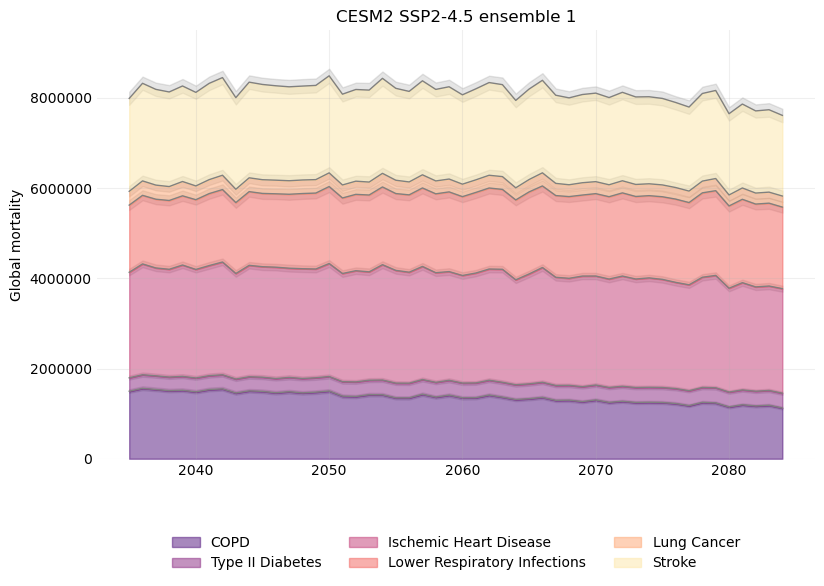

In [14]:
# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25–75% range"

# Create magma colours for each category
cmap = matplotlib.colormaps["magma"]
colors = [cmap(i) for i in np.linspace(0.25, 0.95, len(aligned))]

# Extract mean and quantiles for each health variable
means = []
p1s = []
p2s = []
labels = health_vars

for item in aligned:
    da_mean, da_p1, da_p2 = plotting_data(item, q1, q2)
    means.append(da_mean)
    p1s.append(da_p1)
    p2s.append(da_p2)

means = np.array(means)
p1s = np.array(p1s)
p2s = np.array(p2s)

# Build the cumulative stacking
stack_means = np.cumsum(means, axis=0)
stack_p1s = np.cumsum(p1s, axis=0)
stack_p2s = np.cumsum(p2s, axis=0)

years = ens1["year"].values

plt.figure(figsize=autosize_figure(1, 1))

for i in range(len(means)):
    # Lower boundary
    lower_mean = stack_means[i-1] if i > 0 else 0
    upper_mean = stack_means[i]

    # Uncertainty bounds
    p1 = stack_p1s[i]
    p2 = stack_p2s[i]

    # Uncertainty shading
    plt.fill_between(
        years,
        p1,
        p2,
        color="grey",
        alpha=0.2
    )

    # Stacked band
    plt.fill_between(
        years,
        lower_mean,
        upper_mean,
        color=colors[i],
        alpha=0.5,
        label=labels[i],
    )

    plt.plot(years, upper_mean, color="grey", lw=1)

plt.ylim(0, 9.5e6)
plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.2)

plt.ylabel("Global mortality")
plt.title(f"{model} SSP2-4.5 ensemble 1",)

plt.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.8,
    fontsize=10,
    loc='upper center',           # base location
    bbox_to_anchor=(0.5, -0.15),  # position below the plot
    ncol=3                        # 3 items per row → 2 rows for 6 items
)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()

out_file = f"Global_pm25_mortality_stacked_{model}_{scenario}_{dates}.png"
out_path = os.path.join(SAVE_DIR, out_file)
plt.savefig(out_path)
plt.show()
